# Data loading and Overview #

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

# Paths
resume_path = r"C:\Users\raksh\OneDrive\Documents\GenAI Resume Job Matching\Data\Resumes\resume_data.csv"
job_path = r"C:\Users\raksh\OneDrive\Documents\GenAI Resume Job Matching\Data\Jobs\job_title_des.csv"
match_path = r"C:\Users\raksh\OneDrive\Documents\GenAI Resume Job Matching\Data\Labels\resume_score_details.csv"

# Load data
df_resume = pd.read_csv(resume_path)
df_job = pd.read_csv(job_path)
df_match = pd.read_csv(match_path)

print(df_resume.shape, df_job.shape, df_match.shape)

(9544, 35) (2277, 3) (1031, 172)


In [2]:
# Core columns we will use (freeze schema)
df_match = df_match[
    [
        "input.resume",
        "input.job_description",
        "output.scores.aggregated_scores.macro_scores"
    ]
].rename(
    columns={
        "input.resume": "resume_text",
        "input.job_description": "job_text",
        "output.scores.aggregated_scores.macro_scores": "match_score"
    }
)

df_match.dropna(subset=["resume_text", "job_text"], inplace=True)
df_match.reset_index(drop=True, inplace=True)

df_match.head()

,resume_text,job_text,match_score
0,"ABDULLAH JAWAID \nGulshan e Iqbal, block 2, Ka...",## Job Title: Senior Electrical Engineering Pr...,9.00
1,Team Lead \n Experience Required: 10 to 15 ...,## Job Title: Senior Electrical Engineering Pr...,7.00
2,Team Lead \n Experience Required: 10 to 15 ...,## Job Title: Senior Electrical Project Manage...,9.00
3,MUHAMMAD NADEEM\nELECTRICAL ENGINEER\nPROFILE...,# Job Title: Electrical Engineer - Automation ...,5.96
4,"Milat Road DHA 3, Lahore https://www.linkedin....",### Job Title: International Business Developm...,3.42


# Text Cleaning and Normalization #

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raksh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words
    ]
    return " ".join(tokens)

In [5]:
df_match["resume_clean"] = df_match["resume_text"].apply(preprocess_text)
df_match["job_clean"] = df_match["job_text"].apply(preprocess_text)

# Eda and Skill Intelligence #

In [7]:
# Text length intelligence
df_match["resume_length"] = df_match["resume_clean"].apply(lambda x: len(x.split()))
df_match["job_length"] = df_match["job_clean"].apply(lambda x: len(x.split()))

df_match[["resume_length", "job_length"]].describe()

,resume_length,job_length
count,1021.000000,1021.000000
mean,422.116552,173.942214
std,394.442534,94.995653
min,0.000000,5.000000
25%,225.000000,139.000000
50%,331.000000,161.000000
75%,487.000000,193.000000
max,4085.000000,2180.000000


In [8]:
# Skill density (simple proxy)
df_match["resume_skill_density"] = (
    df_match["resume_clean"].apply(lambda x: len(set(x.split())))
)
df_match["job_skill_density"] = (
    df_match["job_clean"].apply(lambda x: len(set(x.split())))
)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

sns.set(style="whitegrid")

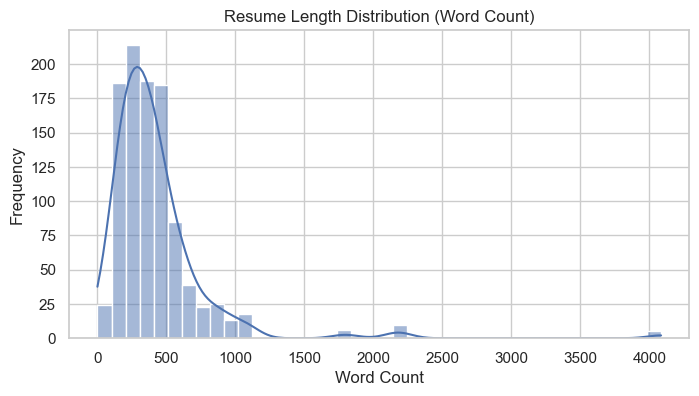

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df_match['resume_length'], bins=40, kde=True)
plt.title("Resume Length Distribution (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

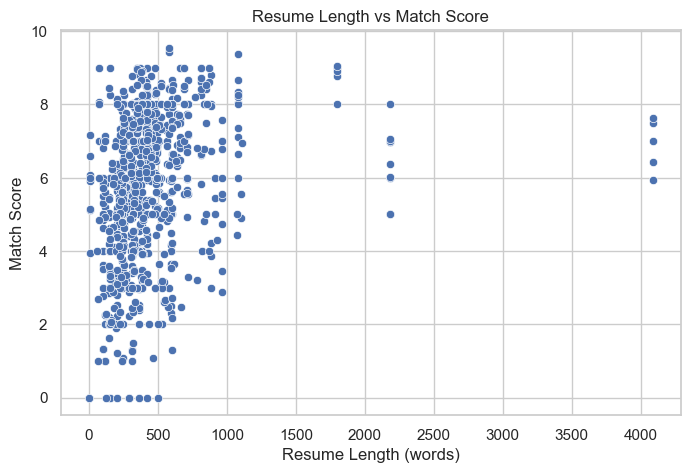

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_match,
    x='resume_length',
    y='match_score'
)
plt.title("Resume Length vs Match Score")
plt.xlabel("Resume Length (words)")
plt.ylabel("Match Score")
plt.show()

In [15]:
all_skills = []

for skills in df_resume['skills']:
    if isinstance(skills, str):
        try:
            skill_list = ast.literal_eval(skills)
            all_skills.extend([s.lower() for s in skill_list])
        except:
            pass

skill_counts = Counter(all_skills)

skills_df = pd.DataFrame(
    skill_counts.most_common(20),
    columns=["Skill", "Frequency"]
)

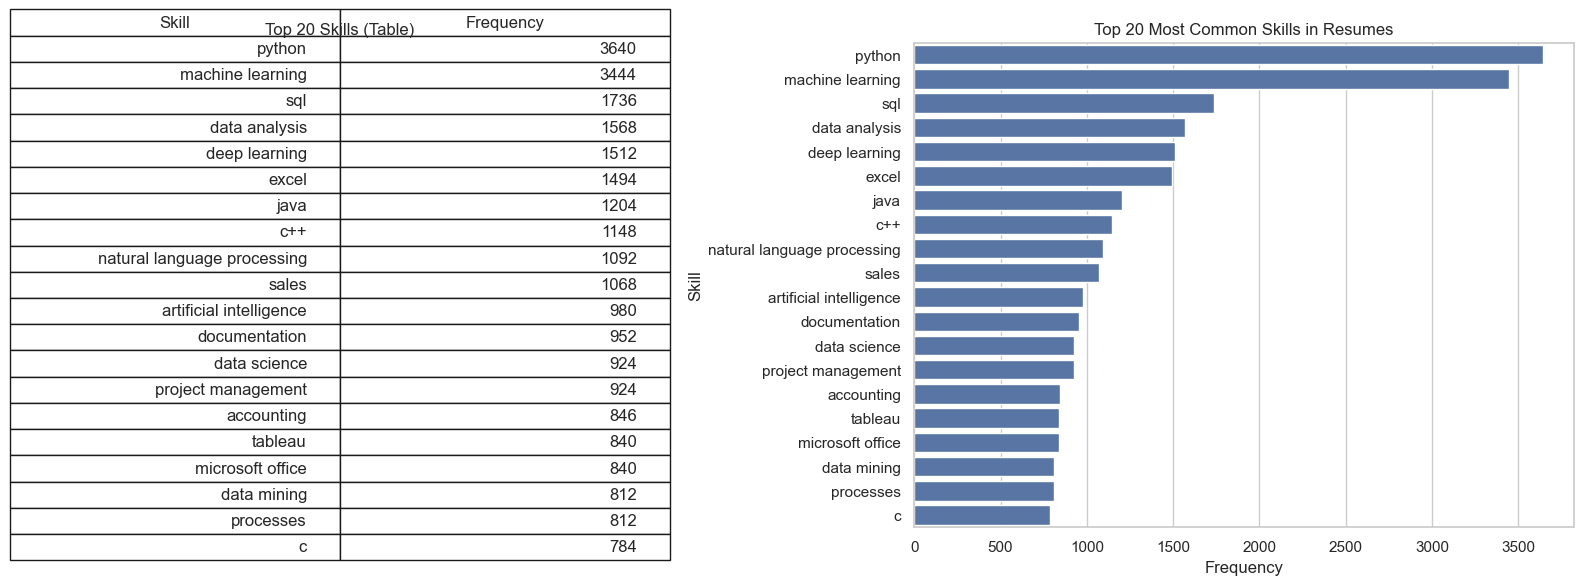

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Table
axes[0].axis('off')
table = axes[0].table(
    cellText=skills_df.values,
    colLabels=skills_df.columns,
    loc='center'
)
table.scale(1, 1.5)
axes[0].set_title("Top 20 Skills (Table)")

# Bar plot
sns.barplot(
    data=skills_df,
    x="Frequency",
    y="Skill",
    ax=axes[1]
)
axes[1].set_title("Top 20 Most Common Skills in Resumes")

plt.tight_layout()
plt.show()

In [17]:
df_resume['num_skills'] = df_resume['skills'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0
)

In [18]:
skill_score_df = df_match.merge(
    df_resume[['skills']],
    left_index=True,
    right_index=True,
    how='inner'
)

skill_score_df['num_skills'] = skill_score_df['skills'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0
)

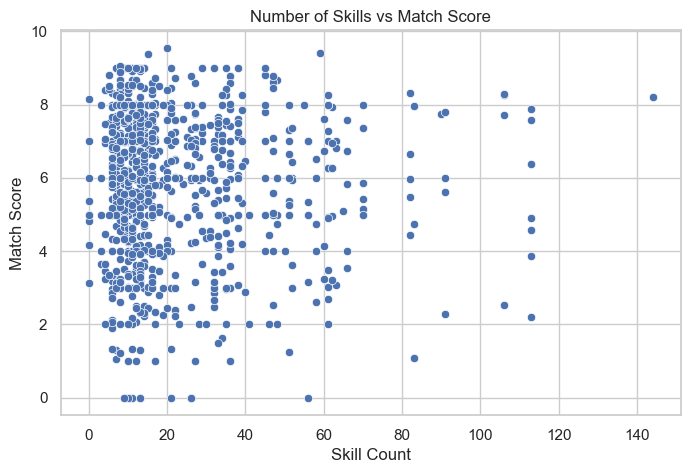

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=skill_score_df,
    x='num_skills',
    y='match_score'
)
plt.title("Number of Skills vs Match Score")
plt.xlabel("Skill Count")
plt.ylabel("Match Score")
plt.show()

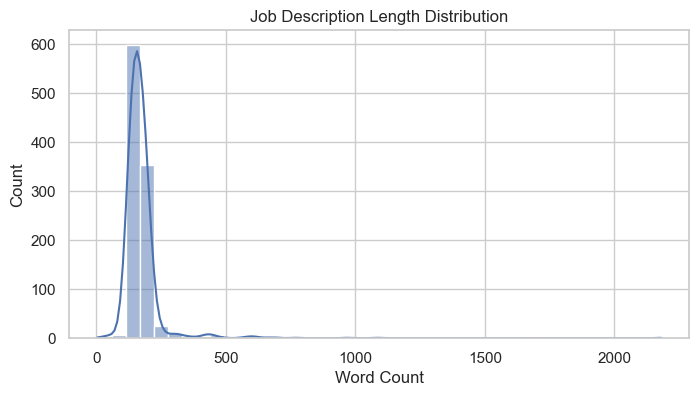

In [20]:
df_match['job_length'] = df_match['job_clean'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8,4))
sns.histplot(df_match['job_length'], bins=40, kde=True)
plt.title("Job Description Length Distribution")
plt.xlabel("Word Count")
plt.show()

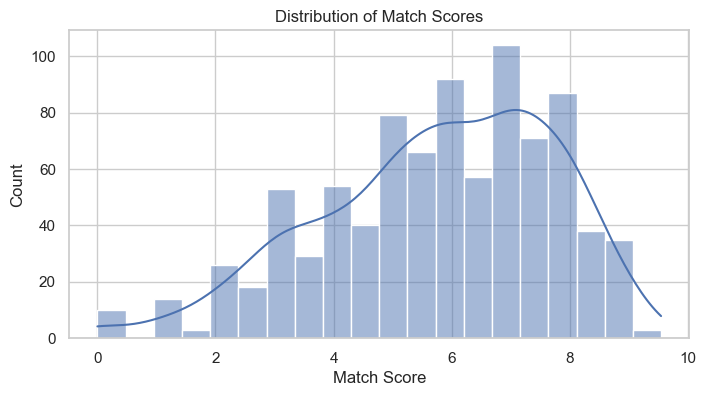

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(
    df_match['match_score'],
    bins=20,
    kde=True
)
plt.title("Distribution of Match Scores")
plt.xlabel("Match Score")
plt.show()

# Feature Engineering and Baseline models #

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
tfidf = TfidfVectorizer(max_features=5000)
tfidf_resume = tfidf.fit_transform(df_match["resume_clean"])
tfidf_job = tfidf.transform(df_match["job_clean"])
df_match["tfidf_similarity"] = [
    cosine_similarity(tfidf_resume[i], tfidf_job[i])[0][0]
    for i in range(len(df_match))
]

In [26]:
# Baseline model
baseline_df = df_match.dropna(subset=["match_score"]).copy()
X_base = baseline_df[["tfidf_similarity"]]
y_base = baseline_df["match_score"]
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
preds = baseline_model.predict(X_test)
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("Baseline R2:", r2_score(y_test, preds))

Baseline RMSE: 1.7462525413974797
Baseline R2: 0.18392189901615963


In [27]:
from sentence_transformers import SentenceTransformer

In [28]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
resume_embeddings = embedder.encode(
    df_match["resume_clean"].tolist(),
    show_progress_bar=True
)
job_embeddings = embedder.encode(
    df_match["job_clean"].tolist(),
    show_progress_bar=True
)
df_match["semantic_similarity"] = [
    cosine_similarity(
        [resume_embeddings[i]],
        [job_embeddings[i]]
    )[0][0]
    for i in range(len(df_match))
]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

# 06_Gen_Ai - Hybrid ML + LLM #

In [29]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler

In [30]:
model_df = df_match.dropna(subset=["match_score"]).copy()

X = model_df[
    [
        "tfidf_similarity",
        "semantic_similarity",
        "resume_length",
        "job_length"
    ]
]

y = model_df["match_score"]

In [31]:
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_scaled, test_size=0.2, random_state=42
)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

In [32]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()
y_test_original = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).ravel()
print("Hybrid RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred)))
print("Hybrid R2:", r2_score(y_test_original, y_pred))

Hybrid RMSE: 1.7125138871829075
Hybrid R2: 0.21515151269026933


In [33]:
# GenAI Explanation Layer (Using Grok  Groq) #
import os
from dotenv import load_dotenv
from groq import Groq

# Explicit path to .env
load_dotenv(r"C:\Users\raksh\OneDrive\Documents\GenAI Resume Job Matching\.env")
api_key = os.getenv("GROQ_API_KEY")
print("API key loaded:", api_key is not None)
client = Groq(api_key=api_key)
print("Groq client initialized successfully ✅")

API key loaded: True
Groq client initialized successfully ✅


In [34]:
def build_prompt(resume_text, job_text, score):
    return f"""
You are a senior hiring manager.

Match Score (0–10): {score:.2f}

RESUME:
{resume_text}

JOB DESCRIPTION:
{job_text}

Explain:
• Why this resume matches or does not match
• Missing or weak skills
• Concrete improvement suggestions
"""

In [35]:
def get_genai_explanation(prompt):
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {"role": "system", "content": "You are an expert hiring manager."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
        max_tokens=500
    )
    return response.choices[0].message.content

In [36]:
# End-to-end demo
row = model_df.iloc[0]

score_scaled = model.predict(
    row[
        [
            "tfidf_similarity",
            "semantic_similarity",
            "resume_length",
            "job_length"
        ]
    ].values.reshape(1, -1)
)

final_score = scaler.inverse_transform(
    score_scaled.reshape(-1, 1)
)[0][0]

prompt = build_prompt(
    row["resume_text"],
    row["job_text"],
    final_score
)

print(get_genai_explanation(prompt))

**Overall Assessment – Match Score: 9.3 / 10**  
Abdullah Jawa id’s résumé aligns very closely with the Senior Electrical Engineering Project Lead role at XYZ Engineering Inc.  He demonstrates the exact mix of technical depth, project‑lead experience, and people‑management that the job description calls for.  Below is a detailed breakdown of why the fit is strong, where the résumé could be tightened, and actionable steps to push the score into the “perfect‑fit” zone.

---

## 1. Why the Resume **Matches** the Role  

| Job Requirement | Evidence in Abdullah’s Resume | How It Satisfies the Requirement |
|-----------------|------------------------------|-----------------------------------|
| **Lead & execute E‑House / switchgear projects** | • Testing & Pre‑Commissioning Lead – E‑House for DS03 (CPS‑4, Iraq)  <br>• Commissioning Lead – ABB E‑House at BNGL (3‑unit & 4‑unit)  <br>• Project Lead – LV Switchboard & Soft‑Starter Panels (AVINA Clean Hydrogen) | Direct, recent leadership of mul

In [37]:
import joblib

joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(model, "ridge_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']